In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, make_scorer

In [2]:
# 前処理データの読み込み
train = pd.read_csv('train_balanced_pre.csv')

In [3]:
# 目的変数 '賃料' と説明変数を指定
X = train.drop(columns=['賃料'])  # 説明変数
y = train['賃料']  # 目的変数

In [4]:
# データを学習用とテスト用に分割（8:2）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# XGBoostモデルの初期化
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)

In [6]:
# ハイパーパラメータのグリッドを定義
param_grid = {
    'n_estimators': [10, 100, 300],
    'max_depth': [2, 5, 10],
    'learning_rate': [0.001, 0.01, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

In [7]:
# RMSEスコアのカスタムスコア関数
def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [8]:
# グリッドサーチの実行
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring=make_scorer(rmse_scorer, greater_is_better=False), cv=5, verbose=1)

In [9]:
# グリッドサーチをトレーニングデータで実行
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None,
                                    random_state=42, ...),
             param_grid={'colsample_bytree': [0.6, 0.8, 1.0],
                         'learning_rate': [0.001, 0.01, 0.1],
                         'max_depth': [2, 5, 10],
                         'n_estimators': [10, 100, 300],
                         'subsample': [0.6, 0.8, 1.0]},
             scoring=make_scorer(rmse_scorer, greater_is_better=False, response_method='predict'),
             verbose=1)

In [10]:
# 最適なハイパーパラメータ
print("Best parameters found: ", grid_search.best_params_)

Best parameters found:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'subsample': 0.6}


# 最適なモデル
best_model = grid_search.best_estimator_

In [11]:
# 学習曲線を表示するためのデータ
eval_set = [(X_train, y_train), (X_test, y_test)]

In [12]:
# ベストモデルでのアーリーストッピングを含む学習
best_model = grid_search.best_estimator_

evals = [(X_train, y_train), (X_test, y_test)]
best_model.fit(X_train, y_train, eval_set=eval_set, eval_metric='rmse', early_stopping_rounds=10, verbose=True)

[0]	validation_0-rmse:95031.27668	validation_1-rmse:96837.80757
[1]	validation_0-rmse:85904.39847	validation_1-rmse:87539.28309
[2]	validation_0-rmse:77867.99744	validation_1-rmse:79432.28928
[3]	validation_0-rmse:70504.90491	validation_1-rmse:71980.64364
[4]	validation_0-rmse:63671.98353	validation_1-rmse:64983.61417
[5]	validation_0-rmse:57579.25653	validation_1-rmse:58761.45285
[6]	validation_0-rmse:52052.28118	validation_1-rmse:53098.43924
[7]	validation_0-rmse:47182.24912	validation_1-rmse:48096.07446
[8]	validation_0-rmse:42719.15916	validation_1-rmse:43510.89123
[9]	validation_0-rmse:38957.62665	validation_1-rmse:39705.46175
[10]	validation_0-rmse:35606.17286	validation_1-rmse:36365.77475
[11]	validation_0-rmse:32267.91154	validation_1-rmse:32920.84075
[12]	validation_0-rmse:29320.97208	validation_1-rmse:29892.55053
[13]	validation_0-rmse:26609.68269	validation_1-rmse:27082.08948
[14]	validation_0-rmse:24141.24911	validation_1-rmse:24567.45274


/home/whitesalena/python/pytorch/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/home/whitesalena/python/pytorch/lib/python3.10/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[15]	validation_0-rmse:21912.36501	validation_1-rmse:22284.70034
[16]	validation_0-rmse:19916.42461	validation_1-rmse:20218.47332
[17]	validation_0-rmse:18167.20044	validation_1-rmse:18391.94759
[18]	validation_0-rmse:16631.71644	validation_1-rmse:16793.54788
[19]	validation_0-rmse:15255.34948	validation_1-rmse:15352.30147
[20]	validation_0-rmse:13969.97089	validation_1-rmse:13997.57077
[21]	validation_0-rmse:12860.48478	validation_1-rmse:12854.02183
[22]	validation_0-rmse:11827.92093	validation_1-rmse:11763.68951
[23]	validation_0-rmse:10897.20823	validation_1-rmse:10773.04381
[24]	validation_0-rmse:10098.93684	validation_1-rmse:9915.90362
[25]	validation_0-rmse:9398.26898	validation_1-rmse:9154.10253
[26]	validation_0-rmse:8750.70450	validation_1-rmse:8433.18722
[27]	validation_0-rmse:8199.16574	validation_1-rmse:7841.69917
[28]	validation_0-rmse:7690.84637	validation_1-rmse:7322.46972
[29]	validation_0-rmse:7180.16588	validation_1-rmse:6842.58765
[30]	validation_0-rmse:6793.19645	va

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

# 学習の際にトレーニングとテストデータのRMSEをモニター
best_model.fit(X_train, y_train, eval_metric='rmse', eval_set=eval_set, verbose=True)

In [13]:
# テストデータでの予測
y_pred = best_model.predict(X_test)

In [14]:
# テストデータでのRMSE評価
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {test_rmse}")

Test RMSE: 1489.6184935829708


In [15]:
# 学習曲線のプロット
results = best_model.evals_result()

In [16]:
# トレーニングと検証データのRMSEを取得
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

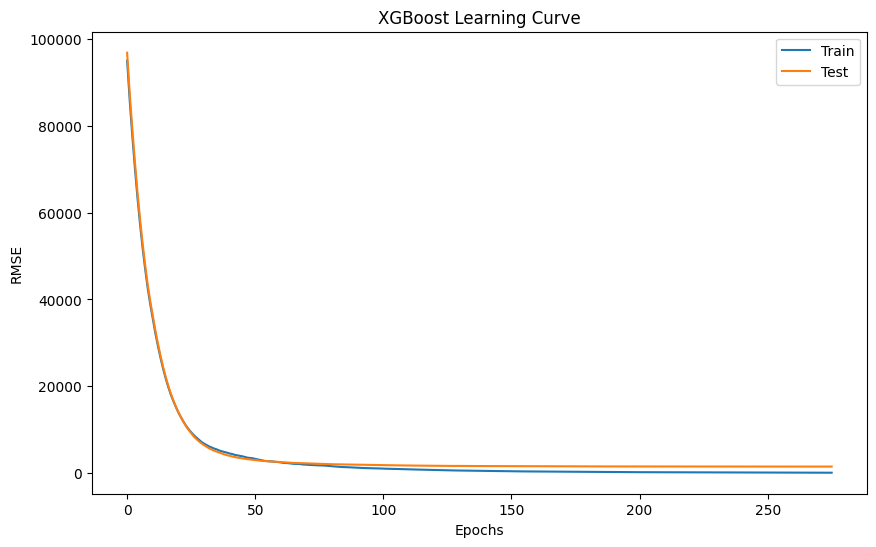

In [17]:
# 学習曲線のプロット
plt.figure(figsize=(10,6))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('XGBoost Learning Curve')
plt.show()

In [18]:
#モデルの保存
with open("model.pickle", mode="wb") as fp:
    pickle.dump(best_model, fp)